Program 2:
Use dimensionality reduction (e.g., PCA or t-SNE) to visualize word embeddings for Q 1. Select 10 words from a specific domain (e.g., sports, technology) and visualize their embeddings. Analyze clusters and relationships. Generate contextually rich outputs using embeddings. Write a program to generate 5 semantically similar words for a given input.

(a) Use dimensionality reduction (e.g., PCA or t-SNE) to visualize word embeddings for program1

In [1]:
# Install required libraries
!pip install gensim numpy matplotlib scikit-learn
#!pip install gensim numpy matplotlib sklearn


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 36.1 MB/s eta 0:00:00


In [2]:
# Import libraries
import gensim.downloader as api
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

In [3]:

#download the model
import gensim.downloader as api
from gensim.models import KeyedVectors
import os

# 1. Define the path where you want to save the model
save_path = "local_word2vec_model.kv"
# Check if the file already exists to avoid re-downloading
if not os.path.exists(save_path):
    print("Downloading the model from gensim-data repository...")
    # This will download the model (around 1.5GB)
    # Using api.load will return a KeyedVectors instance
    word_vectors = api.load("word2vec-google-news-300")

    print(f"Download complete. Saving the model to {save_path}...")
    # 2. Save the model in the gensim KeyedVectors format
    word_vectors.save(save_path)
    print("Model successfully saved.")
else:
    print(f"Model already exists at {save_path}. Loading from local file...")
    # 3. Load the model from the local file if it already exists
    word_vectors = KeyedVectors.load(save_path, mmap='r')
    print("Model successfully loaded from local file.")

[==================================================] 100.0% 1662.8/1662.8MB downloaded
Download complete. Saving the model to local_word2vec_model.kv...
Model successfully saved.


In [4]:
# Function to perform vector arithmetic and find similar words
def explore_word_relationships(word1, word2, word3):
  try:
    # Perform vector arithmetic: word1 - word2 + word3
    result_vector = word_vectors[word1] - word_vectors[word2] + word_vectors[word3]

    # Find the most similar words to the resulting vector
    similar_words = word_vectors.similar_by_vector(result_vector, topn=10)

    # Exclude input words from the results
    input_words = {word1, word2, word3}
    filtered_words = [(word, similarity) for word, similarity in similar_words if word not in input_words]


    print(f"\nWord Relationship: {word1} - {word2} + {word3}")
    print("Most similar words to the result (excluding input words):")

    for word, similarity in filtered_words[:5]: # Show top 5 results
      print(f"{word}: {similarity:.4f}")

    return filtered_words
  except KeyError as e:
    print(f"Error: {e} not found in the vocabulary.")
    return []

In [5]:
# Function to visualize word embeddings using PCA or t-SNE
def visualize_word_embeddings(words, vectors, method='pca'):
  # Reduce dimensionality to 2D
  if method == 'pca':
    reducer = PCA(n_components=2)
  elif method == 'tsne':
    reducer = TSNE(n_components=2, random_state=42, perplexity=3) # Adjust perplexity as needed
  else:
    raise ValueError("Method must be 'pca' or 'tsne'.")
 # Fit and transform the vectors

  #Converts high-dimensional word/document vectors into 2D points for visualization
  reduced_vectors = reducer.fit_transform(vectors)
  # Plot the results

  plt.figure(figsize=(10, 8))
  for i, word in enumerate(words):
    plt.scatter(reduced_vectors[i, 0], reduced_vectors[i, 1], marker='o', color='blue')
    plt.text(reduced_vectors[i, 0] + 0.02, reduced_vectors[i, 1] + 0.02, word, fontsize=12)

  plt.title(f"Word Embeddings Visualization using {method.upper()}")
  plt.xlabel("Component 1")
  plt.ylabel("Component 2")
  plt.grid(True)
  plt.show()


In [6]:
# Example word relationships to explore
words_to_explore = ["king", "man", "woman", "queen", "prince", "princess", "royal", "throne"]
filtered_words = explore_word_relationships("king", "man", "woman")




Word Relationship: king - man + woman
Most similar words to the result (excluding input words):
queen: 0.7301
monarch: 0.6455
princess: 0.6156
crown_prince: 0.5819
prince: 0.5777


In [7]:
# Add the filtered words to the list of words to visualize
words_to_visualize = words_to_explore + [word for word, _ in filtered_words]


In [8]:
# Get vectors for the words to visualize
vectors_to_visualize = np.array([word_vectors[word] for word in words_to_visualize])


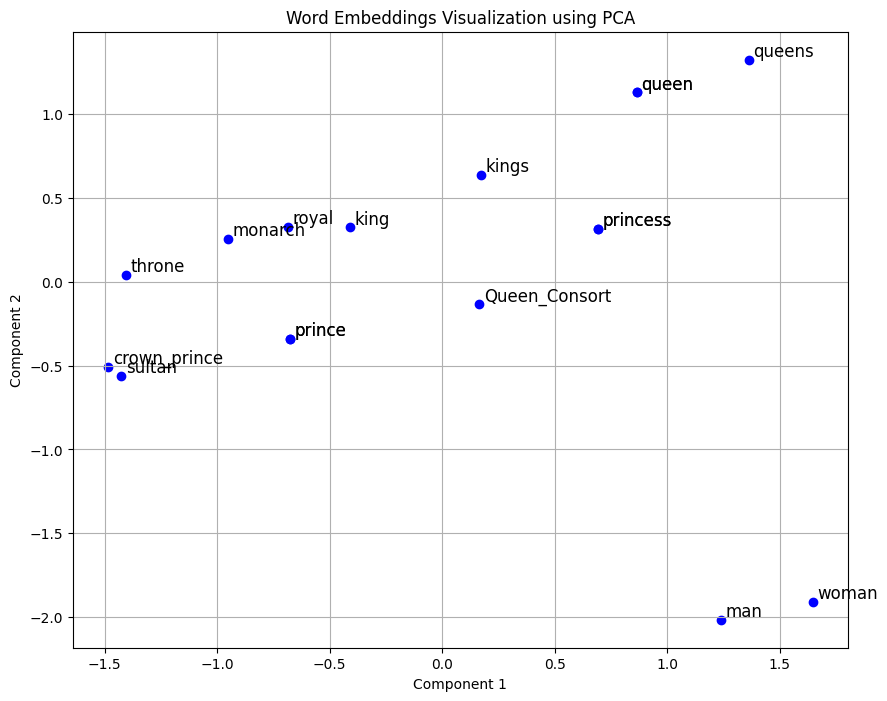

In [9]:
# Visualize using PCA
visualize_word_embeddings(words_to_visualize, vectors_to_visualize, method='pca')



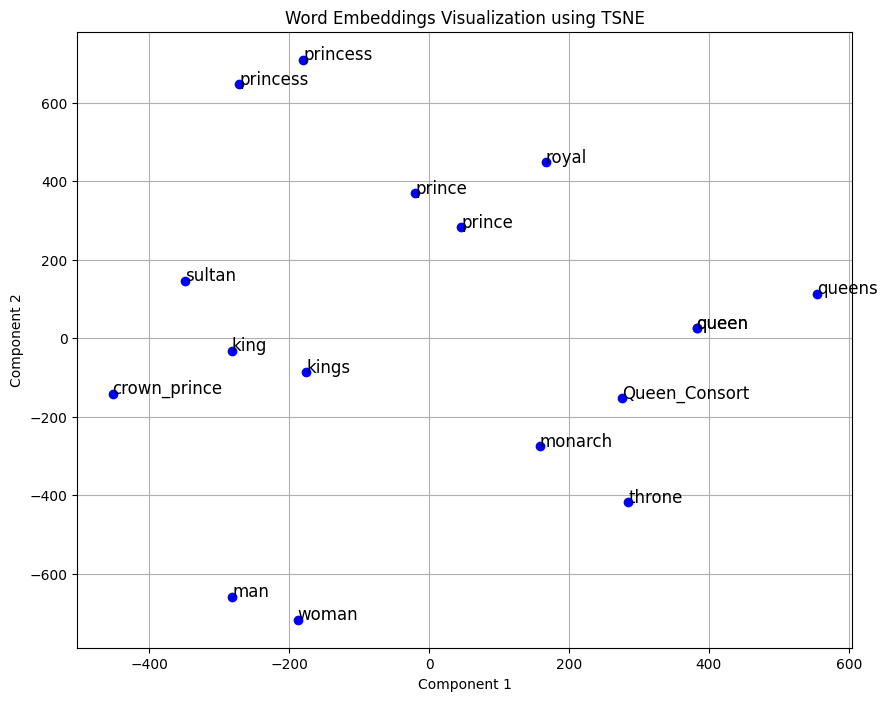

In [10]:
# Visualize using t-SNE
visualize_word_embeddings(words_to_visualize, vectors_to_visualize, method='tsne')



(b)	Select 10 words from a specific domain (e.g., sports, technology) and visualize their embeddings. Analyze clusters and relationships. Generate contextually rich outputs using embeddings. Write a program to generate 5 semantically similar words for a given input.

In [11]:
# Install required libraries
!pip install gensim scikit-learn matplotlib


In [12]:
# Import libraries
import gensim.downloader as api
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE


In [13]:
# Load pre-trained word vectors print("Loading pre-trained word vectors...")
# It is used within the Gensim Python library to download and load a pre-trained Word2Vec model.
#This specific model trained on a massive Google News dataset, provides 300-dimensional word embeddings.
word_vectors = api.load("word2vec-google-news-300") # Load Word2Vec model


In [14]:
word_vectors

In [15]:
# Select 10 words from a specific domain (e.g., technology)
domain_words = ["computer", "software", "hardware", "algorithm", "data", "network", "programming", "machine", "learning", "artificial"]


In [16]:
# Get vectors for the selected words
domain_vectors = np.array([word_vectors[word] for word in domain_words])


In [17]:
np.size(domain_vectors)


3000

In [18]:
# Function to visualize word embeddings using PCA or t-SNE
def visualize_word_embeddings(words, vectors, method='pca', perplexity=5):
  # Reduce dimensionality to 2D
  if method == 'pca':
    #PCA(n_components=2)is a command from the Python machine learning library scikit-learn that
    #initializes a Principal Component Analysis model configured to reduce the dimensionality of a dataset
    #to its two most significant features, called principal components
    reducer = PCA(n_components=2)
  elif method == 'tsne':
    reducer = TSNE(n_components=2, random_state=42, perplexity=perplexity)
  else:
    raise ValueError("Method must be 'pca' or 'tsne'.")

  # Fit and transform the vectors
  reduced_vectors = reducer.fit_transform(vectors)

# Plot the results plt.figure(figsize=(10, 8))
  for i, word in enumerate(words):
    plt.scatter(reduced_vectors[i, 0], reduced_vectors[i, 1], marker='o', color='blue')
    plt.text(reduced_vectors[i, 0] + 0.02, reduced_vectors[i, 1] + 0.02, word, fontsize=12)

  plt.title(f"Word Embeddings Visualization using {method.upper()}")
  plt.xlabel("Component 1")
  plt.ylabel("Component 2")
  plt.grid(True)
  plt.show()


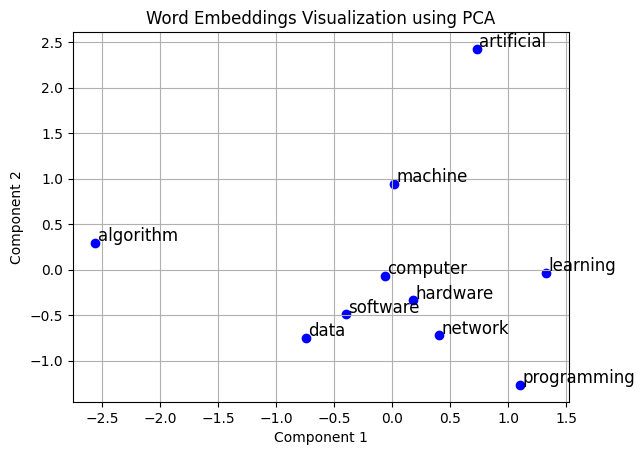

In [19]:
# Visualize using PCA
visualize_word_embeddings(domain_words, domain_vectors, method='pca')



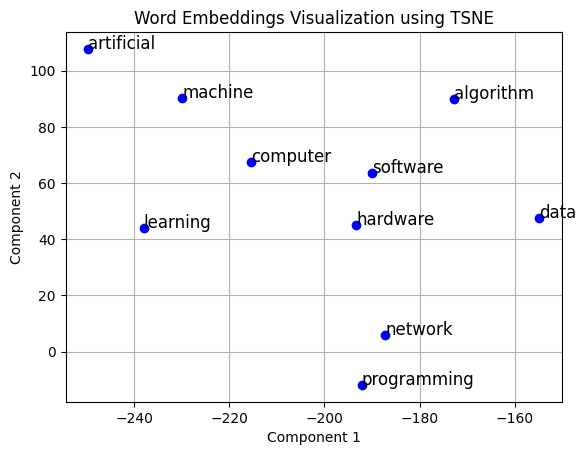

In [20]:
# Visualize using t-SNE
visualize_word_embeddings(domain_words, domain_vectors, method='tsne', perplexity=3)


In [21]:
# Function to generate 5 semantically similar words
def generate_similar_words(word):
  try:
    similar_words = word_vectors.most_similar(word, topn=5)
    print(f"\nTop 5 semantically similar words to '{word}':")
    for similar_word, similarity in similar_words:
      print(f"{similar_word}: {similarity:.4f}")
  except KeyError as e:
    print(f"Error: {e} not found in the vocabulary.")


In [22]:
# Example: Generate similar words for a given input
generate_similar_words("computer")
generate_similar_words("learning")


Top 5 semantically similar words to 'computer':
computers: 0.7979
laptop: 0.6640
laptop_computer: 0.6549
Computer: 0.6473
com_puter: 0.6082

Top 5 semantically similar words to 'learning':
teaching: 0.6602
learn: 0.6365
Learning: 0.6208
reteaching: 0.5810
learner_centered: 0.5739
